In [1]:
import numpy as np, itertools
import tools21cm as t2c, numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

from scipy import special
from scipy.optimize import curve_fit
from scipy.special import jn
from scipy.special import jv
from scipy.integrate import quad
from scipy.spatial import cKDTree
from scipy.interpolate import RectBivariateSpline
from tqdm import tqdm
from ipywidgets import interact

import astropy.units as u
import astropy.constants as cst
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import Angle

from scipy import stats

from matplotlib.colors import LogNorm

In [2]:
def galactic_synch_fg_custom(z, ncells, boxsize, rseed=False):
    """
    Simulated synchrotron emission. Simplified because of removed noise.
    """
    if(isinstance(z, float)):
        z = np.array([z])
    else:
        z = np.array(z, copy=False)

    gf_data = np.zeros((ncells, ncells, z.size))

    if(rseed): 
        np.random.seed(rseed)
	
    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))
    nu_s,A150,beta_,a_syn,Da_syn = 150,513,2.34,2.8,0.1
	
    for i in range(0, z.size):
        nu = t2c.cosmo.z_to_nu(z[i])
        U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z[i])/boxsize
        l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
        C_syn = A150*(1000/l_cb)**beta_
        solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z[i])**2
        AA = np.sqrt(solid_angle*C_syn/2)
        T_four = AA*(X+Y*1j)
        T_real = np.abs(np.fft.ifft2(T_four))   #in Jansky
        gf_data[..., i] = t2c.telescope_functions.jansky_2_kelvin(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
    
    return gf_data.squeeze(), l_cb

def telescope_beam_pattern(x, y, D=45, z=7):
    """
    Returns a 2D Gaussian array representing the telescope beam pattern.

    Parameters
    ----------
    x : ndarray
        Meshgrid x-coordinates.
    y : ndarray
        Meshgrid y-coordinates.
    D : float, optional
        Telescope dish diameter, in meters (default is 45).
    z : float, optional
        Redshift, which is converted to observation frequency (default is 7).

    Returns
    -------
    ndarray
        A 2D Gaussian array representing the telescope beam pattern.

    Notes
    -----
    The Gaussian array is calculated based on the provided dish diameter and redshift.
    """
    freq= t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    theta_0 = 0.6* fwhm
    return np.exp(-((x**2 + y**2) / theta_0**2))

def gaussian_source_2d(x, y, cov):
    """
    Covariance matrix takes two values which provided in arcseconds.
    """
    mean= np.array([0, 0]) #Mean
    #Covariance matrix:
    cov= np.array([[(cov[0]*u.arcsec).to('rad').value, 0], [0, (cov[1]*u.arcsec).to('rad').value]])
    
    x_diff = x- mean[0]
    y_diff = y- mean[1]
    
    inv_cov = np.linalg.inv(cov)

    exponent = -0.5 * (x_diff**2 *inv_cov[0,0] + y_diff**2 *inv_cov[1,1] + 2*x_diff*y_diff*inv_cov[0,1])
    prefactor = 1 / (2*np.pi*np.sqrt(np.linalg.det(cov)))

    return prefactor * np.exp(exponent)

def hirax_layout(N_ant, range):
    """
    Generates a square grid layout of antennas, similar to HIRAX.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).

    Returns
    -------
    ndarray
        An array containing the coordinates of the antennas arranged in a square grid.
        Each row represents the (x, y) coordinates of an antenna.
    """
    x= np.linspace(range[0], range[1], int(np.sqrt(N_ant)))
    X, Y= np.meshgrid(x, x)
    return np.dstack((X, Y)).reshape(-1, 2)

def random_layout(N_ant, range, seed):
    """
    Generates a random layout of antennas within the specified range.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)
    X= np.random.uniform(range[0], range[1], N_ant)
    Y= np.random.uniform(range[0], range[1], N_ant)

    return np.dstack((X,Y)).reshape(-1, 2)

def median_index(list):
    """
    Returns the index of the median value in a numpy list.

    Parameters:
    - list: numpy array or list
        The input array containing numerical values.

    Returns:
    - int
        The index of the element closest to the median value.

    Raises:
    - ValueError: If the input list is empty.
    """
    average = np.mean(list)
    closest_index = np.abs(list - average).argmin()
    return closest_index

def arbitrary_index(list, value):
    closest_index = np.abs(list - value).argmin()
    return closest_index

def visibility_matrix_func(xyz_coord, lmn_coord, redshift, I_sky, beam_pattern):
    """
    Compute the visibility matrix for a given set of antennas and sky image.

    Parameters
    ----------
    xyz_coord : array_like
        Array of x, y, and z coordinates of antennas.
    lmn_coord : array_like
        Array of l, m, and n coordinates representing the direction of the sky image.
    redshift : float
        Redshift observed with 21-cm.
    I_sky : array_like
        Array containing the intensity of the sky image.
    beam_pattern : array_like
        Array representing the beam pattern of the telescope.

    Returns
    -------
    visibility_list : ndarray
        A 1D array of length N_B containing visibility values for each baseline.
    visibility_matrix : ndarray
        A 2D array representing the visibility matrix with shape (N_ant, N_ant).
    """
    N_ant= len(xyz_coord) #Number of antennas
    N_B= int(N_ant*(N_ant-1) / 2) #Number of baselines

    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c / freq

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas

    baseline_coord= np.empty((N_B, xyz_coord.shape[1])) #Initialize a baseline vectors array
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]

        #Calculate distance between antennas
        uv= ((xyz_coord[bb]- xyz_coord[aa]) / lam)
        baseline_coord[i]= uv

        #Calculate the fringe pattern
        fringe= np.exp(-2j * np.pi * (uv[0].value * lmn_coord[:,0] + uv[1].value * lmn_coord[:,1]))

        #Reshape fringe_pattern to match the shape of I_sky
        fringe_reshaped = fringe.reshape(I_sky.shape)

        #Calculate visibility for the current baseline
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)

        visibility_list[i]= visibility

        #Store the visibility value in the array
        visibility_matrix[aa, bb] = visibility
        visibility_matrix[bb, aa] = np.conj(visibility) #Visibility is symmetric

    return visibility_list, visibility_matrix, baseline_coord

def visibility_rotation_synthesis(lmn_coord, rotated_baselines, I_sky, beam_pattern, N_ant):
    N_B= int(N_ant*(N_ant-1) / 2)

    assert np.shape(rotated_baselines)[0] == N_B

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in range(N_B):
        aa, bb= pair_comb[i]
        uv= rotated_baselines[i]
        fringe= np.exp(-2j * np.pi * (uv[0] * lmn_coord[:,0] + uv[1] * lmn_coord[:,1]))
        fringe_reshaped = fringe.reshape(I_sky.shape)
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)
        visibility_list[i]= visibility

        visibility_matrix[aa, bb]=visibility
        visibility_matrix[bb, aa] = np.conj(visibility)

    return visibility_list, visibility_matrix

def Earth_Rotation_Effect(HA, delta):
    HA, delta = HA.to('rad').value, delta.to('rad').value
    
    return np.array([[np.sin(HA), np.cos(HA)], 
                     [-np.sin(delta)*np.cos(HA), np.sin(delta)*np.sin(HA)]])

def visibility_correlation_func(index, baseline_coord, visibility_list, N_B):
    """
    Computes visibility correlation and baseline distances from a given baseline index.

    Parameters:
    - index: int
        Index of the baseline vector.
    - baseline_coord: numpy.ndarray
        Array containing baseline coordinates.
    - visibility_list: numpy.ndarray
        Array containing visibility values.
    - N_B: int
        Total number of baseline vectors.

    Returns:
    - vis_corr: numpy.ndarray
        Array of visibility correlations.
    - baseline_distances_norm: numpy.ndarray
        Array of normalized baseline distances.
    """
    indices= np.linspace(0, N_B-1, N_B)
    indices_combinations= list(itertools.product([index], range(N_B))) #Generate combinations
    baseline_distances= np.empty((len(indices), 2)) #Create empty array for calculating distance between two vectors
    vis_corr= np.empty(len(indices), dtype=np.complex128)

    for i in range(len(indices)):
        ii, jj = indices_combinations[i]
        vis_corr[i]= visibility_list[ii] * np.conj(visibility_list[jj])
        baseline_distances[i]= baseline_coord[jj] - baseline_coord[ii]

    baseline_distances_norm= np.linalg.norm(baseline_distances, axis=1)

    return vis_corr.real, baseline_distances_norm

def uv_space(layout, redshift):
    N_ant=len(layout)
    N_B= int(N_ant*(N_ant-1) / 2)
    pair_comb= list(itertools.combinations(range(N_ant), 2))
    baseline_coord= np.empty((N_B, layout.shape[1]))
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq

    for i in range(N_B):
        aa, bb= pair_comb[i]
        uv= ((layout[bb]- layout[aa]) / lam)
        baseline_coord[i]= uv

    return baseline_coord

def nearest_neighbour_func(freqx, freqy, baselines):
    """
    Finds the nearest neighbors of the given baselines in the frequency domain.

    Parameters:
    - freqx (array-like): Array of x-coordinates of the frequency grid.
    - freqy (array-like): Array of y-coordinates of the frequency grid.
    - baselines (array-like): Array of baseline coordinates.

    Returns:
    - uv_points (ndarray): Array of all frequency grid points.
    - distances (ndarray): Array of distances between baselines and their nearest neighbors.
    - indices (ndarray): Array of indices of the nearest neighbors in the frequency grid.
    """
    u_freq, v_freq= np.meshgrid(freqx, freqy)
    uv_points = np.dstack((u_freq, v_freq)).reshape(-1, 2)
    tree = cKDTree(uv_points)
    distances, indices = tree.query(baselines)

    return uv_points, distances, indices

def indices_reshape(indices, square_size):
    """
    Reshapes a 1D array of indices into a 2D array of indices based on a given square size.

    Parameters:
    indices (numpy.ndarray): 1D array of indices.
    square_size (int): Size of the square grid.

    Returns:
    numpy.ndarray: 2D array of indices.
    """
    array= np.zeros(square_size**2)
    array[indices]= 1
    mask_2d= array.reshape(square_size, square_size)
    indices_2d= np.argwhere(mask_2d==1)

    return indices_2d, mask_2d

def interpolation_func(freq_x, freq_y, image_array, baselines):
    """
    Interpolates the given image array using the provided frequency values and baselines.

    Parameters:
    freq_x (array-like): The x-axis frequency values.
    freq_y (array-like): The y-axis frequency values.
    image_array (array-like): The 2D array representing the image.
    baselines (array-like): The baselines for which interpolation is performed.

    Returns:
    array-like: The interpolated values corresponding to the given baselines.
    """
    spline = RectBivariateSpline(freq_x, freq_y, image_array)
    interp_values = spline.ev(baselines[:, 0], baselines[:, 1])

    return interp_values

def visibility_matrix_func_new_method(xyz_coord, sky_coord, redshift, I_sky, beam_pattern):
    l_coord, m_coord= np.meshgrid(sky_coord, sky_coord)
    N_ant= len(xyz_coord)
    N_B= int(N_ant*(N_ant-1) / 2)
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq
    pair_comb= list(itertools.combinations(range(N_ant), 2))
    baseline_coord= np.empty((N_B, xyz_coord.shape[1]))
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128)
    visibility_list= np.empty(N_B, dtype=np.complex128)

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]
        uv= (xyz_coord[bb]- xyz_coord[aa]) / lam
        baseline_coord[i]= uv
        fringe= np.exp(-2j * np.pi * (uv[0] * l_coord + uv[1] * m_coord))
        vis= np.sum(fringe*I_sky*beam_pattern)
        visibility_list[i]= vis
        visibility_matrix[aa, bb]= vis
        visibility_matrix[bb, aa]= np.conj(vis)
    
    return visibility_list, visibility_matrix, baseline_coord

def image_reconstructing_func(vis_list, baselines, u_min, u_max, bin_len, bin_res):
    """
    Reconstructs an image from visibility data using interferometry.

    Parameters:
    vis_list (array-like): List of visibility values.
    baselines (array-like): List of baseline coordinates.
    u_min (float): Minimum value of the u-coordinate.
    u_max (float): Maximum value of the u-coordinate.
    bin_len (float): Length of the bin.
    bin_res (float): Resolution of the bin.

    Returns:
    array-like: Reconstructed image.
    """
    uv_bin= np.linspace(u_min, u_max, int(bin_len/ bin_res))
    
    uv_plane_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='sum', bins=[uv_bin, uv_bin]).statistic
    uv_sampl_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='count', bins=[uv_bin, uv_bin]).statistic
    uv_plane_binned /= np.where(uv_sampl_binned > 0, uv_sampl_binned, 1)

    x= np.fft.fftshift(np.fft.fftfreq(len(uv_bin), np.diff(uv_bin)[0]))

    return uv_plane_binned, uv_bin, uv_sampl_binned, x

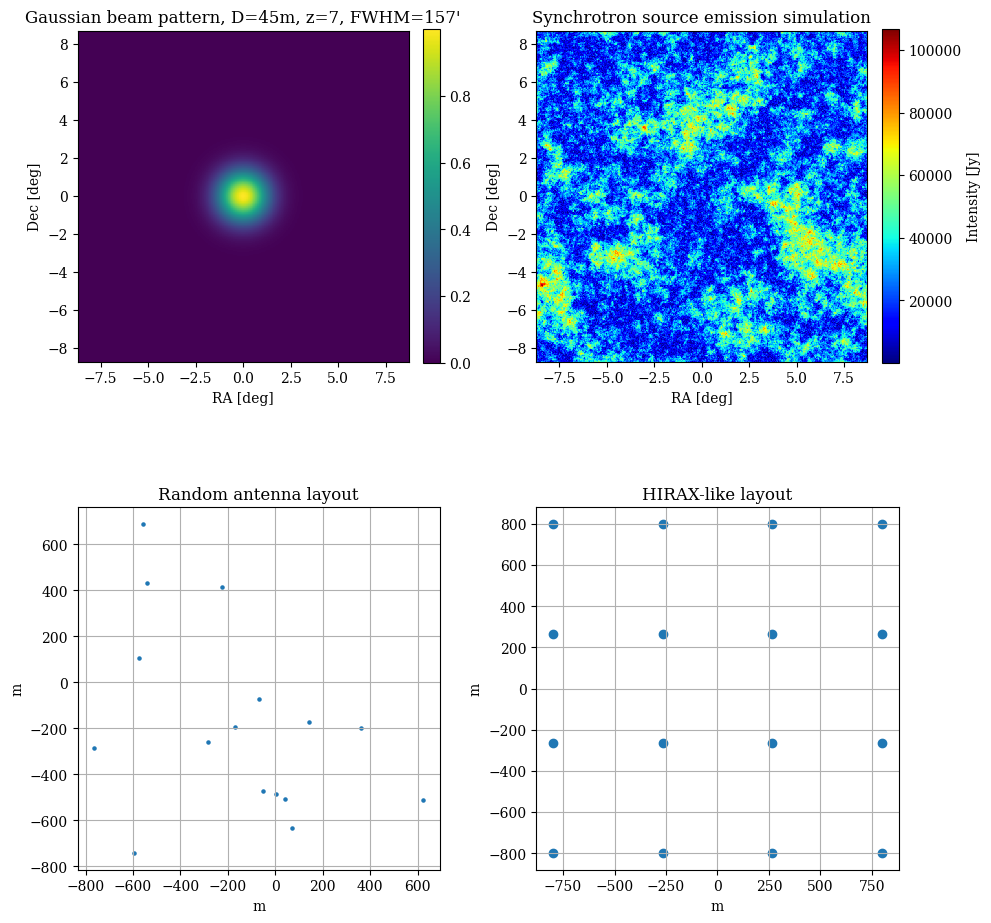

In [3]:
FoV= 17.4*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 512).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
#Generate the coordinates of the telescope layout
# xyz_grid= hirax_layout(11**2, [-1000., 1000.])
# xyz_random= random_layout(11**2, [-1000, 1000], 2024)
xyz_grid= hirax_layout(16, [-800., 800.])
xyz_random= random_layout(16, [-800., 800.], 2023)
#***********************************************

rshift=8.52
#Angular diameter distance for a specified redshift and FoV in deg
FoV= 2 * np.abs(np.degrees(thet[0]))
ang_dim_dist= (FoV*u.deg).to('rad').value * cosmo.angular_diameter_distance(rshift).value

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

beam_pattern= telescope_beam_pattern(l_coord, m_coord)
im0 = axes[0,0].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), beam_pattern, cmap='viridis')
axes[0,0].set_ylabel('Dec [deg]')
axes[0,0].set_xlabel('RA [deg]')
axes[0,0].set_title("Gaussian beam pattern, D=45m, z=7, FWHM=157'")
axes[0,0].set_box_aspect(1)
plt.colorbar(im0, fraction=0.046, pad=0.04)

img, l= galactic_synch_fg_custom(z=[rshift], ncells=len(thet), boxsize=ang_dim_dist, rseed=2024)
im1 = axes[0,1].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), img, cmap='jet')
axes[0,1].set_title("Synchrotron source emission simulation")
axes[0,1].set_ylabel('Dec [deg]')
axes[0,1].set_xlabel('RA [deg]')
axes[0,1].set_box_aspect(1)
plt.colorbar(im1, label='Intensity [Jy]', fraction=0.046, pad=0.04)

axes[1,0].scatter(xyz_random[:, 0], xyz_random[:, 1], s=5)
axes[1,0].set_xlabel("m")
axes[1,0].set_ylabel("m")
axes[1,0].set_title("Random antenna layout")
axes[1,0].grid()
axes[1,0].set_box_aspect(1)

axes[1,1].scatter(xyz_grid[:,0], xyz_grid[:, 1])
axes[1,1].set_xlabel("m")
axes[1,1].set_ylabel("m")
axes[1,1].set_title("HIRAX-like layout")
axes[1,1].grid()
axes[1,1].set_box_aspect(1)

plt.tight_layout()
plt.show()

***
## __Plotting visibility matrices and baselines in the u-v plane for a grid and random array.__

100%|██████████| 120/120 [00:03<00:00, 37.10it/s]


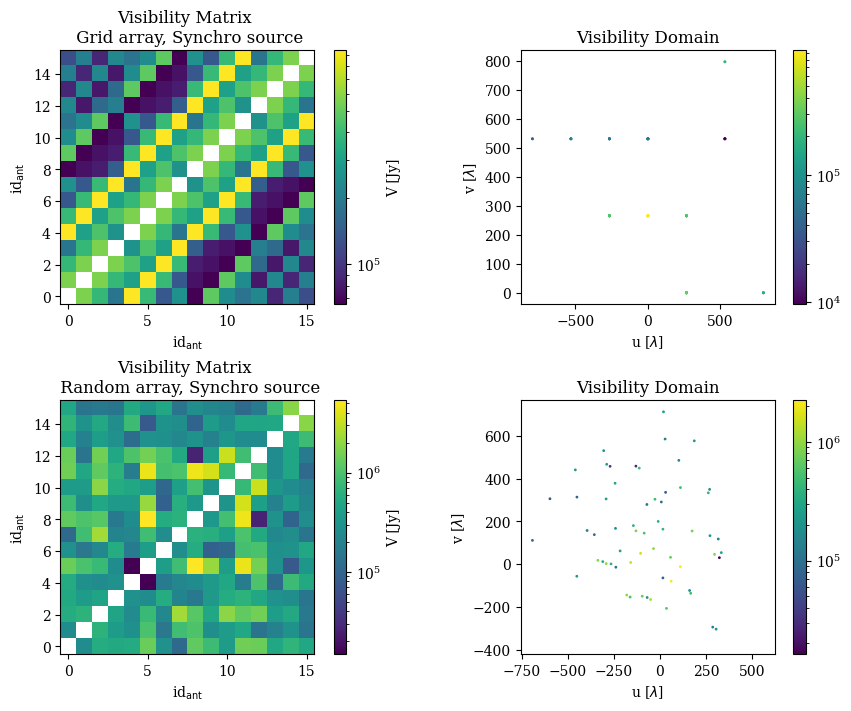

In [4]:
fig, axes= plt.subplots(2, 2, figsize=(9, 7), constrained_layout= True)
rshift=8.52

vis_list0, vis_mx0, bas_coord0= visibility_matrix_func_new_method(xyz_grid, thet, rshift, img, beam_pattern)
im00 = axes[0,0].imshow(np.abs(vis_mx0), origin='lower', cmap='viridis', norm=LogNorm())
axes[0,0].set_xlabel(r'id$_\mathrm{ant}$')
axes[0,0].set_ylabel(r'id$_\mathrm{ant}$')
axes[0,0].set_title('Visibility Matrix \n Grid array, Synchro source')
plt.colorbar(im00, ax=axes[0,0], label='V [Jy]')

im01= axes[0,1].scatter(x=bas_coord0[:,0], y=bas_coord0[:,1], c=vis_list0.real, s=1, norm=LogNorm())
axes[0,1].set_xlabel(r'u [$\lambda$]')
axes[0,1].set_ylabel(r'v [$\lambda$]')
axes[0,1].set_title('Visibility Domain')
axes[0,1].set_box_aspect(1)
plt.colorbar(im01, ax=axes[0,1])


vis_list1, vis_mx1, bas_coord1= visibility_matrix_func_new_method(xyz_random, thet, rshift, img, beam_pattern)
im10 = axes[1,0].imshow(np.abs(vis_mx1), origin='lower', cmap='viridis', norm=LogNorm())
axes[1,0].set_xlabel(r'id$_\mathrm{ant}$')
axes[1,0].set_ylabel(r'id$_\mathrm{ant}$')
axes[1,0].set_title('Visibility Matrix \n Random array, Synchro source')
plt.colorbar(im10, ax=axes[1,0], label='V [Jy]')

im11= axes[1,1].scatter(x=bas_coord1[:,0], y=bas_coord1[:,1], c=vis_list1.real, s=1, norm=LogNorm())
axes[1,1].set_xlabel(r'u [$\lambda$]')
axes[1,1].set_ylabel(r'v [$\lambda$]')
axes[1,1].set_title('Visibility Domain')
axes[1,1].set_box_aspect(1)
plt.colorbar(im11, ax=axes[1,1])

***
## __Plotting the synchrotron source and beam pattern in both real and Fourier space.__

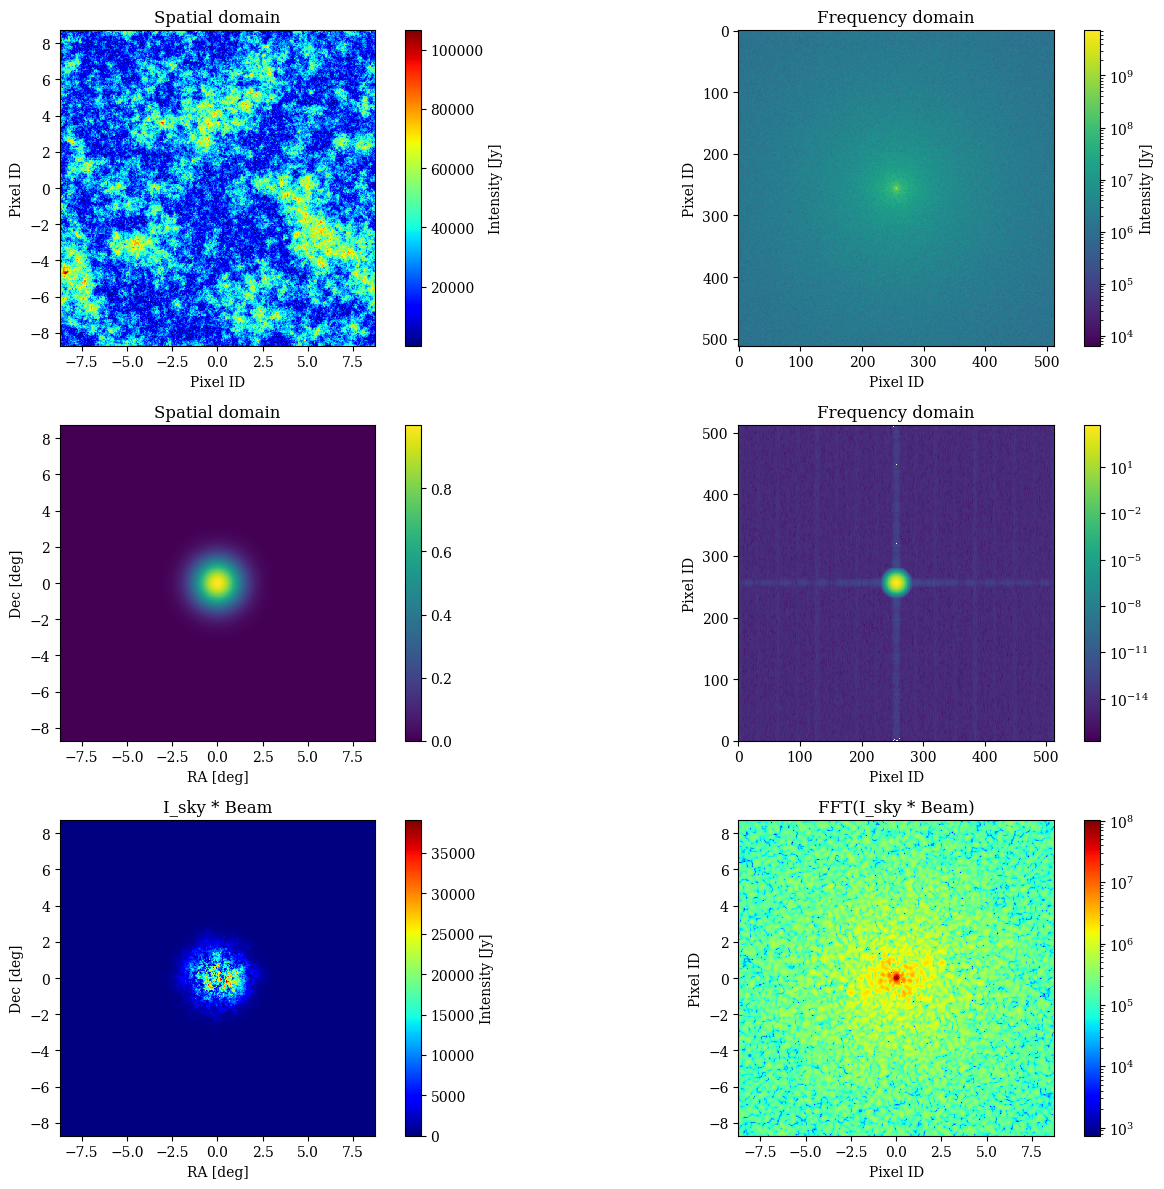

In [5]:
synchro_source_fft= np.fft.fft2(img)
synchro_source_fft= np.fft.fftshift(synchro_source_fft)

beam_pattern_fft= np.fft.fft2(beam_pattern)
beam_pattern_fft= np.fft.fftshift(beam_pattern_fft)

fig, axs = plt.subplots(figsize=(15,12), ncols=2, nrows=3)
axs[0,0].set_title('Spatial domain')
im0= axs[0,0].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), img, cmap='jet')
axs[0,0].set_ylabel('Pixel ID')
axs[0,0].set_xlabel('Pixel ID')
axs[0,0].set_box_aspect(1)
plt.colorbar(im0, label='Intensity [Jy]', fraction=0.046, pad=0.04)

axs[0,1].set_title('Frequency domain')
im1 = axs[0,1].imshow(np.abs(synchro_source_fft), norm=LogNorm())
axs[0,1].set_ylabel('Pixel ID')
axs[0,1].set_xlabel('Pixel ID')
axs[0,1].set_box_aspect(1)
plt.colorbar(im1, label='Intensity [Jy]', fraction=0.046, pad=0.04)


axs[1,0].set_title('Spatial domain')
im2 = axs[1,0].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), beam_pattern, cmap='viridis')
axs[1,0].set_ylabel('Dec [deg]')
axs[1,0].set_xlabel('RA [deg]')
axs[1,0].set_box_aspect(1)
plt.colorbar(im2, fraction=0.046, pad=0.04)

axs[1,1].set_title('Frequency domain')
im3 = axs[1,1].pcolormesh(np.abs(beam_pattern_fft), norm=LogNorm())
axs[1,1].set_ylabel('Pixel ID')
axs[1,1].set_xlabel('Pixel ID')
axs[1,1].set_box_aspect(1)
plt.colorbar(im3, fraction=0.046, pad=0.04)


axs[2,0].set_title('I_sky * Beam')
im4= axs[2,0].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), img * beam_pattern, cmap='jet')
axs[2,0].set_ylabel('Dec [deg]')
axs[2,0].set_xlabel('RA [deg]')
axs[2,0].set_box_aspect(1)
plt.colorbar(im4, label='Intensity [Jy]', fraction=0.046, pad=0.04)

fft_img= np.fft.fftshift(np.fft.fft2(img * beam_pattern))
axs[2,1].set_title('FFT(I_sky * Beam)')
im5= axs[2,1].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), np.abs(fft_img), cmap='jet', norm=LogNorm())
axs[2,1].set_ylabel('Pixel ID')
axs[2,1].set_xlabel('Pixel ID')
axs[2,1].set_box_aspect(1)
plt.colorbar(im5, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

***
## __Sampling the FFT image with nearest-neighbours points and with interpolated values.__

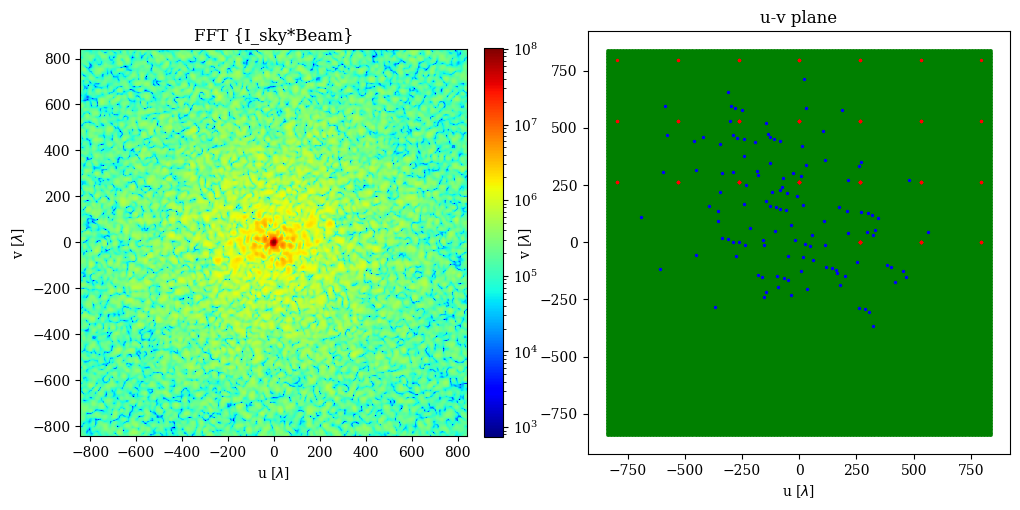

In [6]:
# Computing the frequency range of the FFT image
uu= np.fft.fftfreq(img.shape[0], np.diff(thet)[0])
vv= np.fft.fftfreq(img.shape[1], np.diff(thet)[0])
uu= np.fft.fftshift(uu)
vv= np.fft.fftshift(vv)

u_freq, v_freq= np.meshgrid(uu, vv)

fig, axs= plt.subplots(1, 2, figsize=(12, 6))

im0= axs[0].pcolormesh(u_freq, v_freq, np.abs(fft_img), cmap='jet', norm=LogNorm())
axs[0].set_title('FFT {I_sky*Beam}')
axs[0].set_xlabel(r'u [$\lambda$]')
axs[0].set_ylabel(r'v [$\lambda$]')
axs[0].set_box_aspect(1)
plt.colorbar(im0, fraction=0.046, pad=0.04)

axs[1].scatter(u_freq, v_freq, color='green', s=0.5)
axs[1].scatter(bas_coord0[:,0], bas_coord0[:,1], color='red', s=2)
axs[1].scatter(bas_coord1[:,0], bas_coord1[:,1], color='blue', s=2)
axs[1].set_title('u-v plane')
axs[1].set_xlabel(r'u [$\lambda$]')
axs[1].set_ylabel(r'v [$\lambda$]')
axs[1].set_box_aspect(1)

### __1) Nearest neighbours method.__

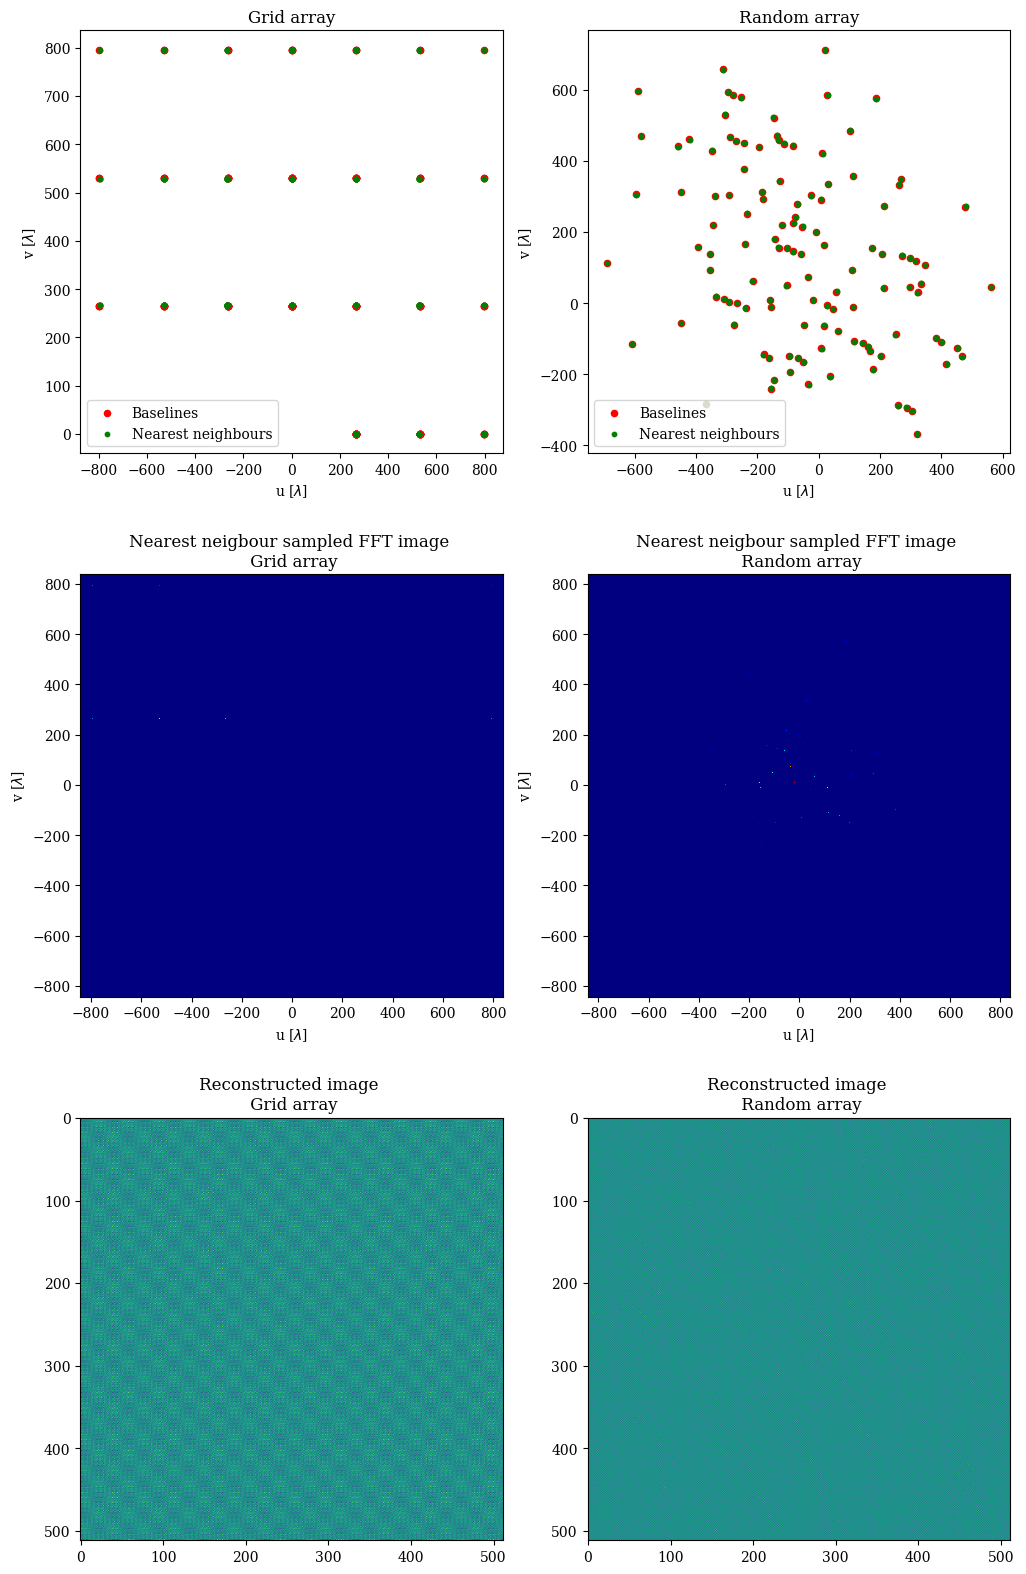

In [7]:
#Nearest neighbours for the grid layout
uv_points, distances_grid, indices_grid= nearest_neighbour_func(uu, vv, bas_coord0)
#Nearest neighbours for the random layout
uv_points, distances_random, indices_random= nearest_neighbour_func(uu, vv, bas_coord1)


#Sampling the values of the image fft at nearest neighbour indices
indx_random2d, mask_random= indices_reshape(indices_random, len(uu))
indx_grid2d, mask_grid= indices_reshape(indices_grid, len(uu))

# fft_img_random= fft_img[indx_random2d[:,0], indx_random2d[:,1]]
# fft_img_grid= fft_img[indx_grid2d[:,0], indx_grid2d[:,1]]

fftimg_masked_grid= fft_img * mask_grid
fftimg_masked_random= fft_img * mask_random

#Storing the values of the image fft at nearest neighbour indices
val_grid_nn= fft_img[indx_grid2d[:,0], indx_grid2d[:,1]]
val_random_nn= fft_img[indx_random2d[:,0], indx_random2d[:,1]]


fig, axs= plt.subplots(3, 2, figsize=(12, 20))

axs[0,0].scatter(bas_coord0[:,0], bas_coord0[:,1], s=20, label='Baselines', color='red')
axs[0,0].scatter(uv_points[indices_grid, 0],  uv_points[indices_grid, 1], s=10, label='Nearest neighbours', color='green')
axs[0,0].set_title('Grid array')
axs[0,0].set_xlabel(r'u [$\lambda$]')
axs[0,0].set_ylabel(r'v [$\lambda$]')
axs[0,0].legend(loc= 'lower left')
axs[0,0].set_box_aspect(1)

axs[0,1].scatter(bas_coord1[:,0], bas_coord1[:,1], s=20, label='Baselines', color='red')
axs[0,1].scatter(uv_points[indices_random, 0],  uv_points[indices_random, 1], s=10, label='Nearest neighbours', color='green')
axs[0,1].set_title('Random array')
axs[0,1].set_xlabel(r'u [$\lambda$]')
axs[0,1].set_ylabel(r'v [$\lambda$]')
axs[0,1].legend(loc= 'lower left')
axs[0,1].set_box_aspect(1)

im0= axs[1,0].pcolormesh(u_freq, v_freq, np.abs(fftimg_masked_grid), cmap='jet')
axs[1,0].set_title('Nearest neigbour sampled FFT image \n Grid array')
axs[1,0].set_xlabel(r'u [$\lambda$]')
axs[1,0].set_ylabel(r'v [$\lambda$]')
axs[1,0].set_box_aspect(1)
#plt.colorbar(im0, fraction=0.046, pad=0.04)

im1= axs[1,1].pcolormesh(u_freq, v_freq, np.abs(fftimg_masked_random), cmap='jet')
axs[1,1].set_title('Nearest neigbour sampled FFT image \n Random array')
axs[1,1].set_xlabel(r'u [$\lambda$]')
axs[1,1].set_ylabel(r'v [$\lambda$]')
axs[1,1].set_box_aspect(1)
#plt.colorbar(im1, fraction=0.046, pad=0.04)

im2= axs[2,0].imshow(np.fft.ifft2(fftimg_masked_grid).real)
axs[2,0].set_title('Reconstructed image \n Grid array')
axs[2,0].set_box_aspect(1)
#plt.colorbar(im2, fraction=0.046, pad=0.04)

im3= axs[2,1].imshow(np.fft.ifft2(fftimg_masked_random).real)
axs[2,1].set_title('Reconstructed image \n Random array')
axs[2,1].set_box_aspect(1)
#plt.colorbar(im3, fraction=0.046, pad=0.04)

### __2) RectBivariateSpline interpolation method__

In [8]:
# Removing repeating baseline coordinates for a grid array
# (and making the length the same as in using the nearest neighbours method)
# Storing the x and y values of coordinates as complex numbers to find the unique values
bas_coord0_unique= [np.round(x, 5) + 1j*np.round(y, 5) for (x,y) in bas_coord0]
bas_coord0_unique= np.unique(bas_coord0_unique)
bas_coord0_unique= np.column_stack((bas_coord0_unique.real, bas_coord0_unique.imag))

# Interpolating the values on a complex fft_img array
interp_random_cx= interpolation_func(uu, vv, fft_img, bas_coord1)
interp_grid_cx= interpolation_func(uu, vv, fft_img, bas_coord0_unique)

# Interpolating the values on a real and imaginary fft_img separately
interp_random_real= interpolation_func(uu, vv, fft_img.real, bas_coord1)
interp_random_im= interpolation_func(uu, vv, fft_img.imag, bas_coord1)
interp_grid_real= interpolation_func(uu, vv, fft_img.real, bas_coord0_unique)
interp_grid_im= interpolation_func(uu, vv, fft_img.imag, bas_coord0_unique)

#Compunting relative difference between the two methods
rel_diff_grid_cx= np.abs(np.abs(interp_grid_cx) - np.abs(val_grid_nn)) / np.abs(val_grid_nn)
rel_diff_random_cx= np.abs(np.abs(interp_random_cx) - np.abs(val_random_nn)) / np.abs(val_random_nn)

rel_diff_grid_separate= np.abs((np.abs(interp_grid_real + 1j*interp_grid_im) - np.abs(val_grid_nn)) / np.abs(val_grid_nn))
rel_diff_random_separate= np.abs((np.abs(interp_random_real + 1j*interp_random_im) - np.abs(val_random_nn)) / np.abs(val_random_nn))

### __Differences between two methods__

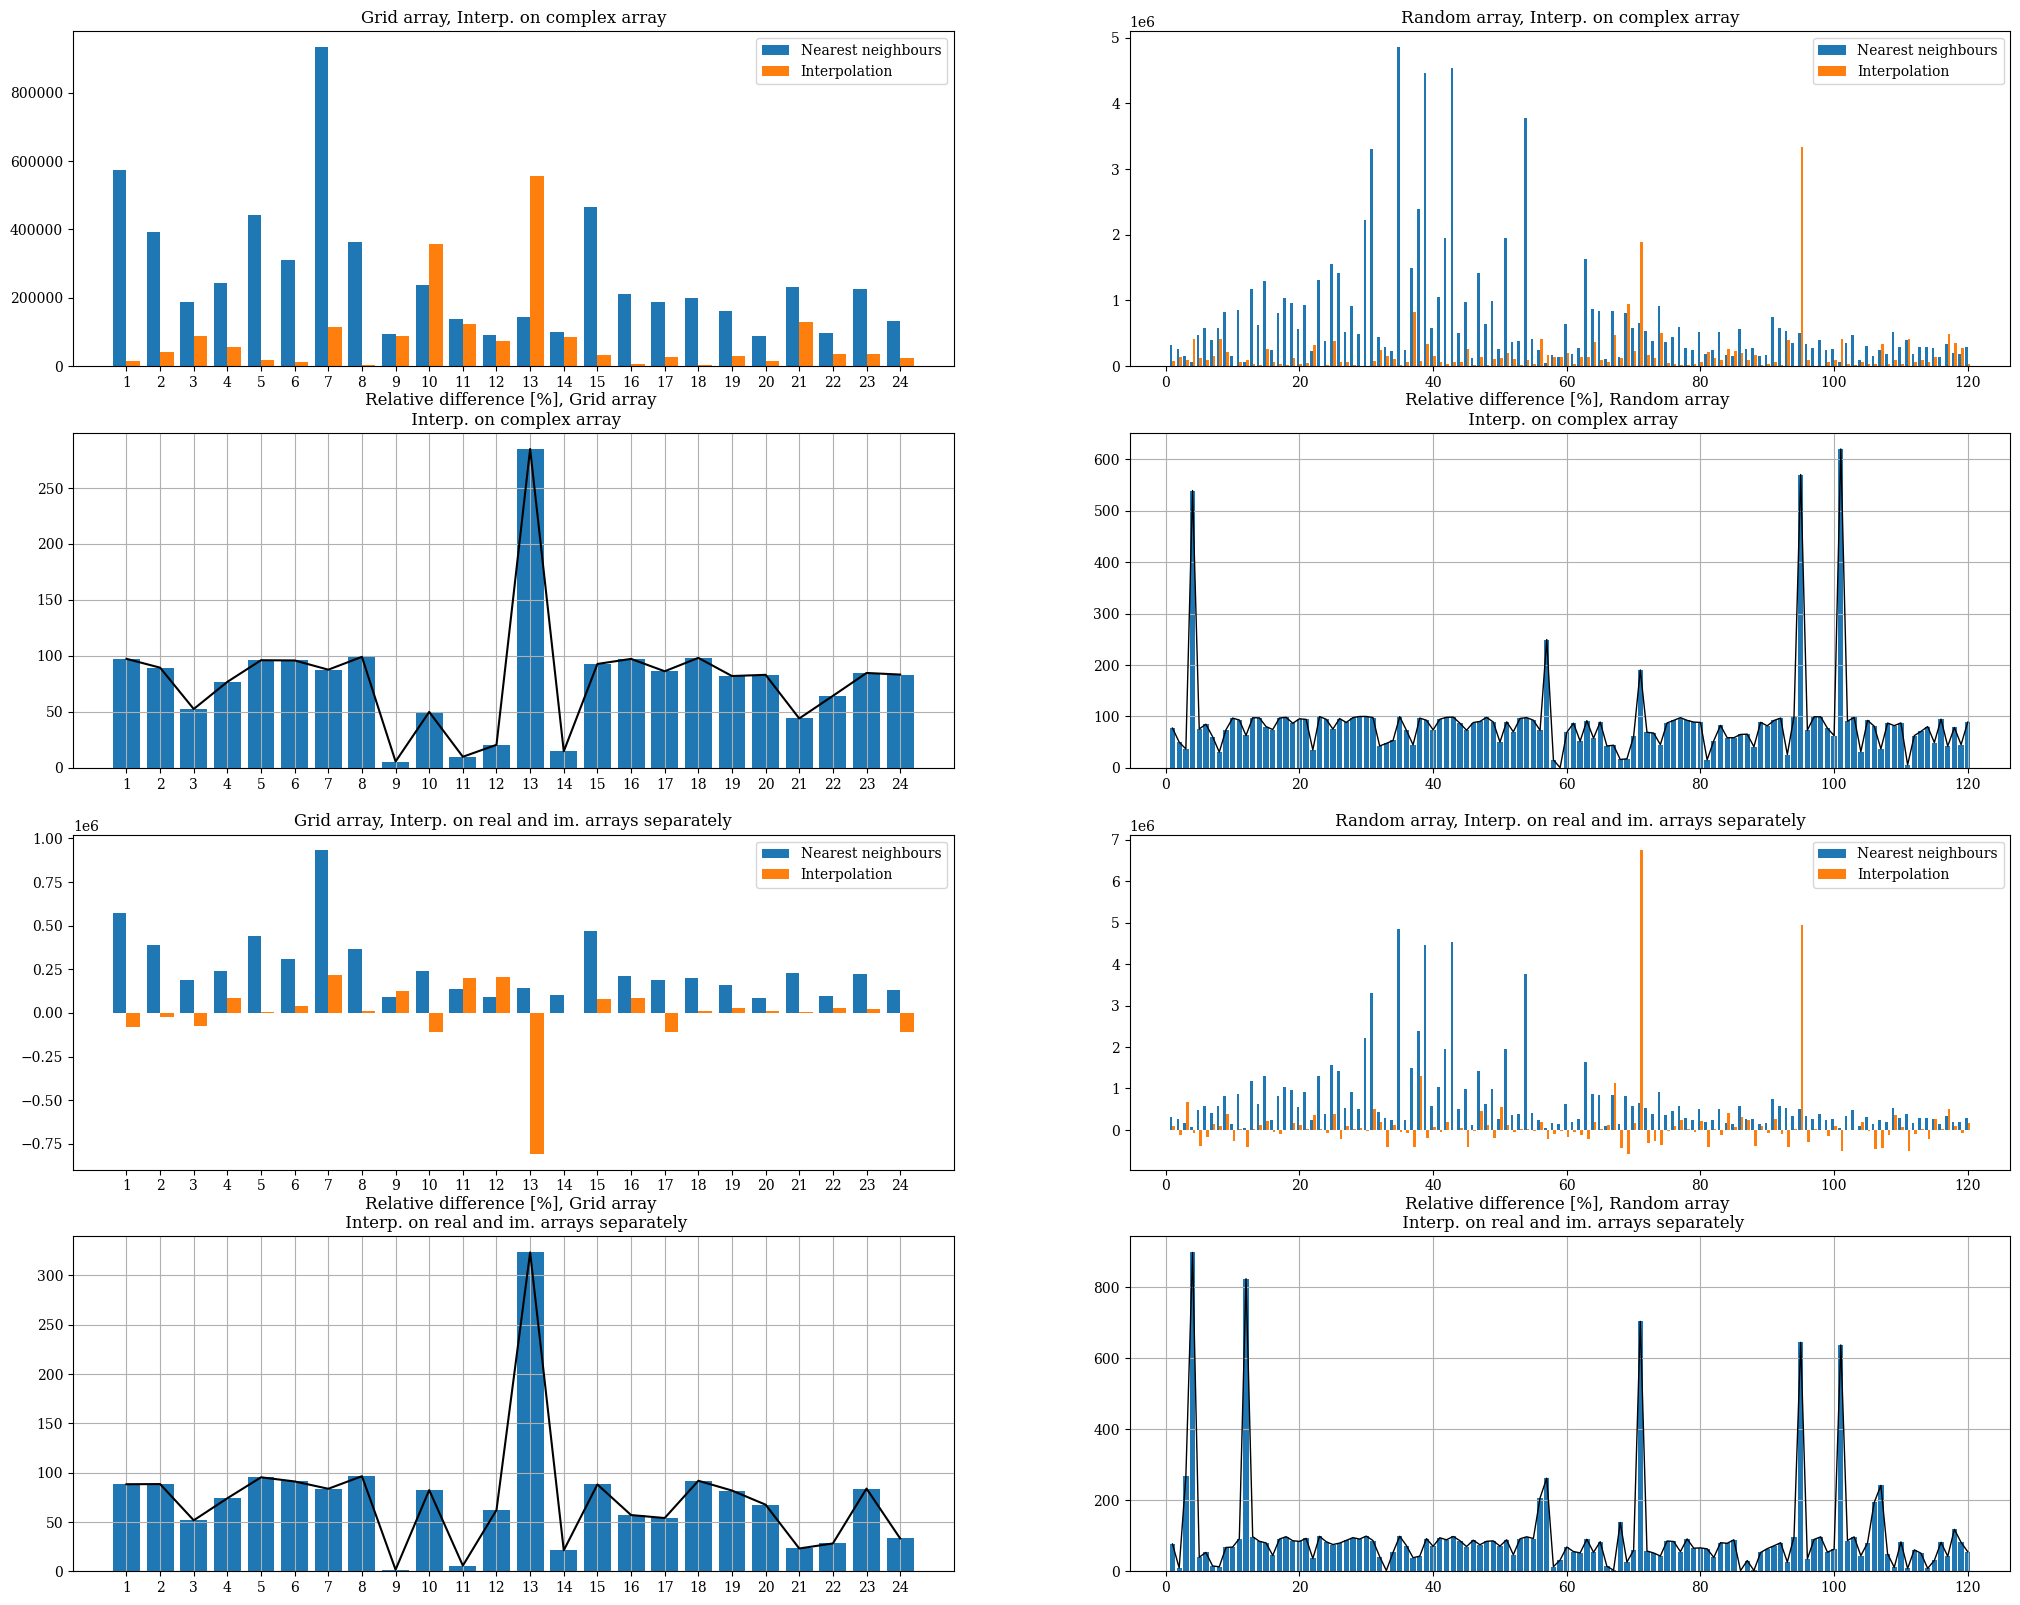

In [9]:
# Comparing the values from the two methods

fig, axs= plt.subplots(4, 2, figsize=(25, 20))

axs[0,0].bar(np.linspace(1, len(val_grid_nn), len(val_grid_nn))-0.2, np.abs(val_grid_nn), label='Nearest neighbours', width=0.4)
axs[0,0].bar(np.linspace(1, len(interp_grid_cx), len(interp_grid_cx))+0.2, np.abs(interp_grid_cx), label='Interpolation', width=0.4)
axs[0,0].set_title('Grid array, Interp. on complex array')
axs[0,0].set_xticks(np.linspace(1, len(val_grid_nn), len(val_grid_nn)))
axs[0,0].legend()

axs[1,0].bar(np.linspace(1, len(val_grid_nn), len(val_grid_nn)), rel_diff_grid_cx*100)
axs[1,0].plot(np.linspace(1, len(val_grid_nn), len(val_grid_nn)), rel_diff_grid_cx*100, color='k')
axs[1,0].set_title('Relative difference [%], Grid array \n Interp. on complex array')
axs[1,0].set_xticks(np.linspace(1, len(val_grid_nn), len(val_grid_nn)))
axs[1,0].grid()


axs[0,1].bar(np.linspace(1, len(val_random_nn), len(val_random_nn))-0.2, np.abs(val_random_nn), label='Nearest neighbours', width=0.4)
axs[0,1].bar(np.linspace(1, len(interp_random_cx), len(interp_random_cx))+0.2, np.abs(interp_random_cx), label='Interpolation', width=0.4)
axs[0,1].set_title('Random array, Interp. on complex array')
axs[0,1].legend()

axs[1,1].bar(np.linspace(1, len(val_random_nn), len(val_random_nn)), rel_diff_random_cx*100)
axs[1,1].plot(np.linspace(1, len(val_random_nn), len(val_random_nn)), rel_diff_random_cx*100, color='k', linewidth=1.)
axs[1,1].set_title('Relative difference [%], Random array \n Interp. on complex array')
axs[1,1].grid()


axs[2,0].bar(np.linspace(1, len(val_grid_nn), len(val_grid_nn))-0.2, np.abs(val_grid_nn), label='Nearest neighbours', width=0.4)
axs[2,0].bar(np.linspace(1, len(interp_grid_real), len(interp_grid_real))+0.2, 
                  interp_grid_real+interp_grid_im, label='Interpolation', width=0.4)
axs[2,0].set_title('Grid array, Interp. on real and im. arrays separately')
axs[2,0].set_xticks(np.linspace(1, len(val_grid_nn), len(val_grid_nn)))
axs[2,0].legend()

axs[2,1].bar(np.linspace(1, len(val_random_nn), len(val_random_nn))-0.2, np.abs(val_random_nn), label='Nearest neighbours', width=0.4)
axs[2,1].bar(np.linspace(1, len(interp_random_real), len(interp_random_real))+0.2, 
                  interp_random_real+interp_random_im, label='Interpolation', width=0.4)
axs[2,1].set_title('Random array, Interp. on real and im. arrays separately')
axs[2,1].legend()


axs[3,0].bar(np.linspace(1, len(val_grid_nn), len(val_grid_nn)), rel_diff_grid_separate*100)
axs[3,0].plot(np.linspace(1, len(val_grid_nn), len(val_grid_nn)), rel_diff_grid_separate*100, color='k')
axs[3,0].set_title('Relative difference [%], Grid array \n Interp. on real and im. arrays separately')
axs[3,0].set_xticks(np.linspace(1, len(val_grid_nn), len(val_grid_nn)))
axs[3,0].grid()

axs[3,1].bar(np.linspace(1, len(val_random_nn), len(val_random_nn)), rel_diff_random_separate*100)
axs[3,1].plot(np.linspace(1, len(val_random_nn), len(val_random_nn)), rel_diff_random_separate*100, color='k', linewidth=1.)
axs[3,1].set_title('Relative difference [%], Random array \n Interp. on real and im. arrays separately')
axs[3,1].grid()